In [3]:
print("Welcome to TITANIC dataset:)")

Welcome to TITANIC dataset:)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
train_data = pd.read_csv("train_titanic.csv")
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_data.shape

(891, 12)

In [7]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
train_data.columns.isnull().sum()

np.int64(0)

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [34]:
train_data.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
#Confision matrix kullanacağız ; Classsification kullanırız burada

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_data["Sex"]  = le.fit_transform(train_data["Sex"])
#MAN-> 1
#WOMAN->0
train_data["Sex"].unique()

array([1, 0])

In [12]:
man_died_count = len(train_data[(train_data["Sex"] == 1) & (train_data["Survived"] == 0)])
woman_died_count = len(train_data[(train_data["Sex"] == 0) & (train_data["Survived"] == 0)])

man_survived_count = len(train_data[(train_data["Sex"] == 1) & (train_data["Survived"] == 1)])
woman_survived_count = len(train_data[(train_data["Sex"] == 0) & (train_data["Survived"] == 1)])

man_percentage_survive = (man_survived_count / len(train_data[train_data["Sex"] == 1]))*100
woman_percentage_survive = (woman_survived_count / len(train_data[train_data["Sex"] == 0]))*100

print(f"{man_survived_count + woman_survived_count} people survived \n{man_survived_count} man \n{woman_survived_count} women")
print()
print(f"{man_died_count + woman_died_count} people died \n{man_died_count} man \n{woman_died_count} women")
print()
print(f"{man_percentage_survive:.3f}% man survived \n{woman_percentage_survive:.3f}% woman survived")

342 people survived 
109 man 
233 women

549 people died 
468 man 
81 women

18.891% man survived 
74.204% woman survived


In [15]:
train_data["Pclass"].unique()

array([3, 1, 2])

In [21]:
Pclass_1_mean_fare = train_data[train_data["Pclass"] == 1]["Fare"].mean()
Pclass_2_mean_fare = train_data[train_data["Pclass"] == 2]["Fare"].mean()
Pclass_3_mean_fare = train_data[train_data["Pclass"] == 3]["Fare"].mean()

print(f"Class 1 average ticket fare: {Pclass_1_mean_fare:.2f}$")
print(f"Class 2 average ticket fare: {Pclass_2_mean_fare:.2f}$")
print(f"Class 3 average ticket fare: {Pclass_3_mean_fare:.2f}$")

Class 1 average ticket fare: 84.15$
Class 2 average ticket fare: 20.66$
Class 3 average ticket fare: 13.68$


/var/folders/s3/kqmlr2qj7ld1gv4_m6hhb8700000gn/T/ipykernel_19498/845758739.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


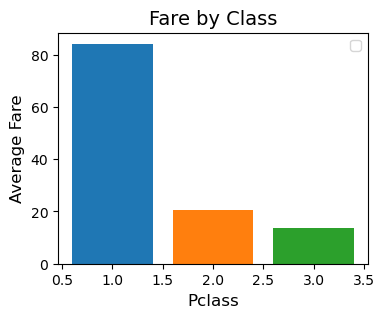

In [24]:
classes = [1, 2, 3]
fares = [Pclass_1_mean_fare, Pclass_2_mean_fare, Pclass_3_mean_fare]

plt.figure(figsize = (4,3))
plt.bar(classes, fares, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Fare by Class', fontsize=14)
plt.xlabel('Pclass', fontsize=12)
plt.ylabel('Average Fare', fontsize=12)

plt.legend()

In [31]:
'''
#   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  

 10  Cabin        204 non-null    object 

 bu columnlara bak!
'''

'\n#   Column       Non-Null Count  Dtype  \n---  ------       --------------  -----  \n 5   Age          714 non-null    float64\n\n 10  Cabin        204 non-null    object \n\n bu columnlara bak!\n'

In [35]:
train_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,C


In [39]:
train_data["Ticket"].nunique()
#number of unique

681

In [40]:
print(train_data["Age"].mean())
print(train_data["Age"].median())
print(train_data["Age"].mode())

29.69911764705882
28.0
0    24.0
Name: Age, dtype: float64


In [42]:
train_data["Age"].fillna(train_data["Age"].median(), inplace = True)
#Mean and Median was closely each other.

In [45]:
train_data["Age"].isnull().sum()

np.int64(0)